In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [16]:
# MODEL_A = "ollama/llama3:8b"        # weaker / baseline model
# MODEL_B = "ollama/qwen3:8b"         # stronger / comparison model
MODEL_A = "ollama/llama2"        # weaker / baseline model
MODEL_B = "ollama/llama3:8b"         # stronger / comparison model

In [3]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("length  :", len(dataset_raw))
print("input   :", sample.input)
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

length  : 14042
input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


In [4]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("length  :", len(dataset))
print("input   :", sample.input)
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

length  : 14042
input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.
target  : B  <- letter now
choices : ['0', '4', '2', '6']


In [5]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "high_school_computer_science"
)

print(f"My subset: {len(MY_SUBSET)} questions")


Astronomy: 152 questions
My subset: 100 questions


In [6]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

In [10]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)


Output()

Status  : success
Model   : ollama/llama3:8b
Accuracy: 0.8


In [11]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    rows = []
    for sample in log.samples:
        rows.append({
            'id': sample.id,
            'epoch': sample.epoch,
            'score': 1 if sample.score.value == 'C' else 0,
            'subject': sample.metadata['subject']
        })
    return pd.DataFrame(rows)

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

[04/08/26 22:33:30] WARNING  The 'score' field is deprecated. Access sample scores through 'scores'   ]8;id=624686;file:///home/d/AIsafety/.venv/lib/python3.12/site-packages/inspect_ai/_util/logger.py\logger.py]8;;\:]8;id=689391;file:///home/d/AIsafety/.venv/lib/python3.12/site-packages/inspect_ai/_util/logger.py#220\220]8;;\
                             instead.                                                                              

   id  epoch  score    subject
0   1      1      1  astronomy
1   2      1      1  astronomy
2   3      1      1  astronomy
3   4      1      0  astronomy
4   5      1      1  astronomy

Accuracy: 80.0%


In [12]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    if ci not in (0.95, 0.99):
        raise NotImplementedError
    mean = scores.mean()
    coeff = 1.96 if ci == 0.95 else 2.58
    se_clt = (scores.var(ddof=1) / len(scores)) ** 0.5
    return (mean - coeff * se_clt, mean, mean + coeff * se_clt)


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    means = df.groupby('id')['score'].mean().to_numpy()
    return ci_accuracy_basic(means)

In [27]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.223  (narrower on average)

✓ All tests passed!


In [ ]:
k_values = [1,3,5,7]

def run(k):
    log = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=k, limit=10)[0]
    return ci_accuracy(log_to_df(log))
ci_lowers, accuracies, ci_uppers = zip(*[run(k) for k in k_values])

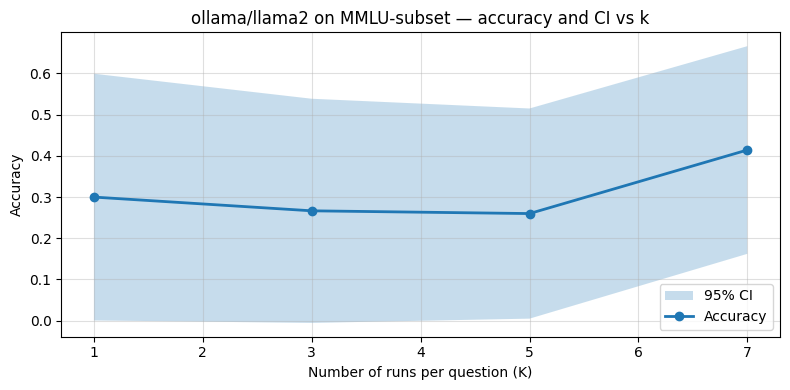

In [18]:
plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Look at how fast the band narrows. At what point does running another epoch stop being worth it?
Does more K change your estimate of the model's accuracy, or just your confidence in it?
What does this tell you about how to allocate your evaluation budget?

It seems that 1 epoch is enough

K does not change model accuracy, just confidence in it

The more epochs, the more each sample expensiever to evaluate, so you need to realize, how expensive does a new sample cost

In [ ]:
question_ids  = [e.id for e in astronomy_subset]
dataset_sizes = range(20, len(question_ids) + 1, 20)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

def run(n):
    log = eval(mmlu_subset(astronomy_subset), model=MODEL_A, limit=n)[0]
    return ci_accuracy(log_to_df(log))
ci_lowers, accuracies, ci_uppers = zip(*[run(n) for n in dataset_sizes])

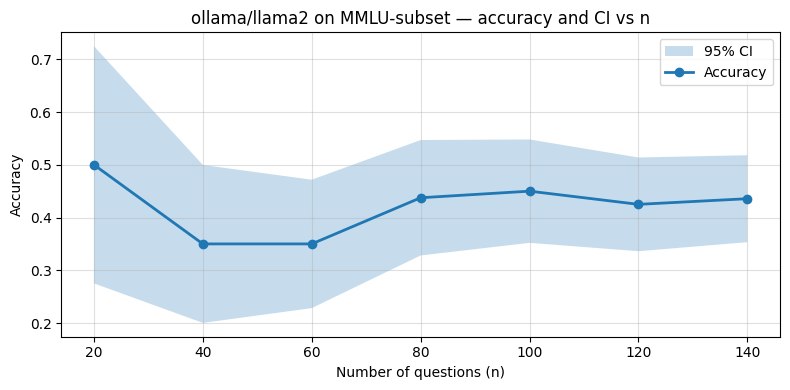

In [28]:
plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

At what n does the accuracy line start to feel stable?
Compare that number to the size of MY_SUBSET — are you in the reliable region?
Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

The accuracy line starts to feel stable at n = 80

MY_SUBSET contains 100 samples, it is more or less enough

n has more impact, but after plateau K may help to reduce the error a bit more

In [31]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    _, p_value  = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff   = scores1.mean() - scores2.mean()
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [33]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


In [ ]:
df_a = log_to_df(eval(mmlu_subset(MY_SUBSET), model=MODEL_A)[0])
df_b = log_to_df(eval(mmlu_subset(MY_SUBSET), model=MODEL_B)[0])

In [38]:
significance_by_paired_ttest(df_a['score'], df_b['score'])

(np.float64(5.982326548144948e-07), np.float64(-0.31), True)

Write down the p-value and the mean difference you got. Is the gap significant? 
Is it large enough to matter in practice?
What would change your conclusion: more questions, a different subject, or a different model pair?

p-value -> 0

mean difference is 0.31

It is great difference in practice

I think llama3 outperforms llama2, so only different model pair would change the conclusion. Or reducing sample size